Imports

In [1]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from datasets import load_from_disk

 Reproducibility + device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Paths

In [3]:
DATASET_PATH = "D:/plant_disease_data/bd_crop_dataset"
MODEL_SAVE_DIR = "E:/Research/Multi-crop-plant-disease-detection/models"
OUTPUT_DIR = "E:/Research/Multi-crop-plant-disease-detection/outputs"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "logs"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)

Load local dataset

In [4]:
ds = load_from_disk(DATASET_PATH)
print(ds)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 86467
    })
    valid: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 24698
    })
    test: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 12423
    })
})


Check dataset basics

In [5]:
print("Train size:", len(ds["train"]))
print("Valid size:", len(ds["valid"]))
print("Test size:", len(ds["test"]))

print("\nFirst sample:")
print(ds["train"][0].keys())
print(ds["train"][0]["label"])
print(ds["train"][0]["label_name"])

Train size: 86467
Valid size: 24698
Test size: 12423

First sample:
dict_keys(['image', 'label', 'label_name'])
0
Banana_Black_Pitting_or_Banana_Rust


Build class names

In [6]:
train_labels = ds["train"]["label_name"]
class_names = sorted(list(set(train_labels)))
num_classes = len(class_names)

label2id = {name: i for i, name in enumerate(class_names)}
id2label = {i: name for name, i in label2id.items()}

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 94
First 10 classes: ['Banana_Black_Pitting_or_Banana_Rust', 'Banana_Crown_Rot', 'Banana_Healthy', 'Banana_fungal_disease', 'Banana_leaf_Banana_Scab_Moth', 'Banana_leaf_Black_Sigatoka', 'Banana_leaf_Healthy', 'Banana_leaf__Black_Leaf_Streak', 'Banana_leaf__Panama_Disease.', 'Cauliflower_Bacterial_spot_rot']


 Sample image show

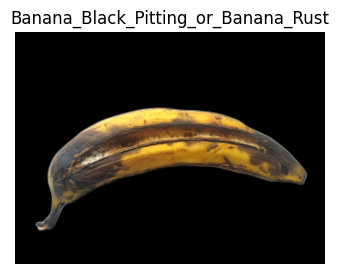

In [7]:
sample = ds["train"][0]

plt.figure(figsize=(4, 4))
plt.imshow(sample["image"])
plt.title(sample["label_name"])
plt.axis("off")
plt.show()

 Transforms

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

 PyTorch dataset wrapper

In [9]:
class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"]
        label_name = item["label_name"]

        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        image = image.convert("RGB")
        label = label2id[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

 Create datasets and dataloaders

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

 One batch test

In [14]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 5 labels:", labels[:5])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 5 labels: tensor([17, 67, 68, 89,  6])


 Build MobileNetV2

In [15]:
def build_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenetv2(num_classes)
model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\user/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 8.73MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=94, bias=True)
)


 Loss, optimizer, scheduler

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

 Training and validation functions

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return epoch_loss, acc, precision, recall, f1

In [18]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return epoch_loss, acc, precision, recall, f1

Full pilot training loop

In [19]:
EPOCHS = 5
best_val_f1 = 0.0
best_model_path = os.path.join(MODEL_SAVE_DIR, "mobilenetv2_best.pth")

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")


Epoch [1/5]


Train Loss: 0.7799 | Train Acc: 0.7748 | Train F1: 0.7662
Val   Loss: 0.3097 | Val   Acc: 0.8855 | Val   F1: 0.8798
Best model saved.

Epoch [2/5]


Train Loss: 0.2857 | Train Acc: 0.8955 | Train F1: 0.8938
Val   Loss: 0.1983 | Val   Acc: 0.9221 | Val   F1: 0.9192
Best model saved.

Epoch [3/5]


Train Loss: 0.2038 | Train Acc: 0.9219 | Train F1: 0.9213
Val   Loss: 0.1575 | Val   Acc: 0.9363 | Val   F1: 0.9357
Best model saved.

Epoch [4/5]


Train Loss: 0.1650 | Train Acc: 0.9350 | Train F1: 0.9346
Val   Loss: 0.1555 | Val   Acc: 0.9341 | Val   F1: 0.9327

Epoch [5/5]


Train Loss: 0.1371 | Train Acc: 0.9449 | Train F1: 0.9447
Val   Loss: 0.1249 | Val   Acc: 0.9493 | Val   F1: 0.9485
Best model saved.


Training history table

In [20]:
history_df = pd.DataFrame(history)
history_df 

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.779871,0.774770,0.766241,0.309730,0.885456,0.879762
1,2,0.285713,0.895486,0.893785,0.198319,0.922058,0.919154
2,3,0.203826,0.921924,0.921279,0.157513,0.936270,0.935693
3,4,0.165017,0.934958,0.934587,0.155474,0.934124,0.932676
4,5,0.137115,0.944869,0.944705,0.124894,0.949308,0.948500


 Plot training curves

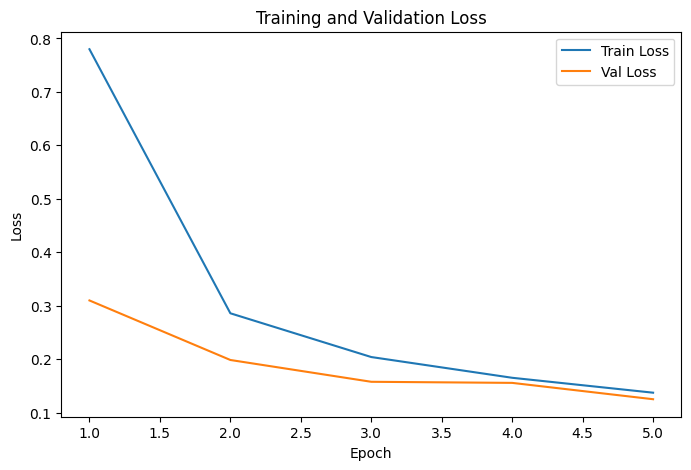

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

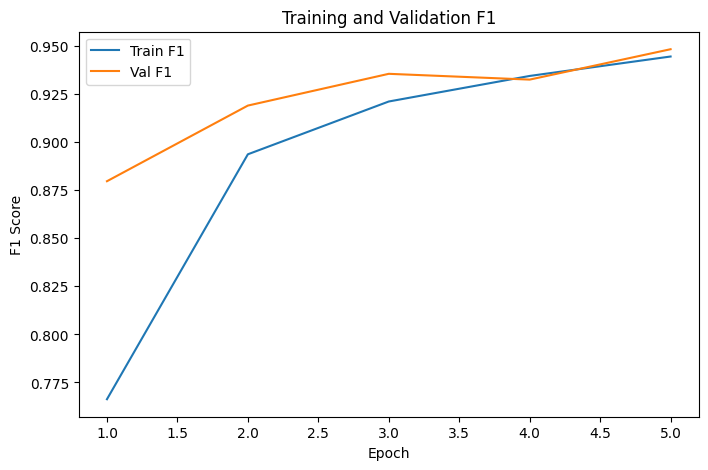

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training and Validation F1")
plt.legend()
plt.show()

Load best model

In [23]:
best_model = build_mobilenetv2(num_classes)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Best model loaded from:", best_model_path)

Best model loaded from: E:/Research/Multi-crop-plant-disease-detection/models\mobilenetv2_best.pth


 Test evaluation

In [24]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")

Testing: 100%|██████████| 389/389 [07:06<00:00,  1.10s/it]

Test Accuracy : 0.9472
Test Precision: 0.9483
Test Recall   : 0.9472
Test F1-score : 0.9462


 Save pilot results

In [25]:
results_df = pd.DataFrame([{
    "Model": "MobileNetV2",
    "Val Best F1": best_val_f1,
    "Test Accuracy": test_acc,
    "Test Precision": test_precision,
    "Test Recall": test_recall,
    "Test F1-Score": test_f1
}])

results_path = os.path.join(OUTPUT_DIR, "tables", "mobilenetv2_pilot_results.csv")
os.makedirs(os.path.dirname(results_path), exist_ok=True)

results_df.to_csv(results_path, index=False)
results_df

,Model,Val Best F1,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,MobileNetV2,0.9485,0.947195,0.948253,0.947195,0.946178
